In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys

sys.path.append("../")

from tqdm import tqdm_notebook
from src import NesterovMUFunc, Nesterov, STM


In [14]:
class NesterovMUFuncEnemy(NesterovMUFunc):

    # def estimation_grad(self, x, direction_point, x_star):
    #     g = self.grad(x)
    #     size = self.alpha * np.linalg.norm(g)
    #     diff = direction_point - x_star
    #     noise = diff / np.linalg.norm(diff) * size
    #     est = g - noise
    #     return est

    def make_noise(self, x):
        noise = np.random.randn(self.d)
        g = self.grad(x)
        return np.linalg.norm(g) * self.alpha * noise / np.linalg.norm(noise)

    def estimation_grad(self, x, *args, **kwargs):
        return self.grad(x) + self.make_noise(x)


In [25]:
def plot(iters: int = 100, alphas = (0.1,), mu = 1, L = 10, dig_mu = 3, dig_a = 2, name: str = "def"):
    d = 1001
    start = np.zeros(d)
    start[0] = 1000
    
    with sns.plotting_context("notebook"), sns.axes_style("darkgrid"):
        plt.figure(figsize=(14, 6), dpi=120)
        # plt.figure(figsize=(4, 3), bbox_inches="tight")
        noised = []
        for alpha in alphas:
            nesterov = NesterovMUFuncEnemy(L=L, mu=mu, alpha=alpha, d=d)
            nesterov_algo = Nesterov(start=start, L=L, mu=mu, func=nesterov)
            noised.append(nesterov_algo)

        nesterov_true = NesterovMUFuncEnemy(L=L, mu=mu, alpha=0, d=d)
        heavy_true = Nesterov(start=start, L=L, mu=mu, func=nesterov_true)
        # stm_true = STM(start=start, L=L, mu=mu, func=nesterov_true)

        for _ in tqdm_notebook(range(iters)):
            for algo in noised:
                algo.step()
            # stm.step()
            heavy_true.step()
            # stm_true.step()
        xst = heavy_true.history
        plt.semilogy(np.arange(len(xst)), [nesterov(x) for x in xst], label="Without noise RE-AGM")
        for algo in noised:
            xs = algo.history
            alpha = algo.func.alpha
            plt.semilogy(np.arange(len(xs)), [nesterov(x) for x in xs], label=rf"Noised RE-AGM, $\alpha$ = {alpha:.{dig_a}f}")
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
        plt.xlabel(r"Iterations $N$", fontsize=20)
        plt.ylabel(r"$f(x^N) - f^*$", fontsize=20)
        # plt.title(fr"RE-AGM convergence with different $\alpha$, $\mu$ = {mu:.{dig_mu}f}, $L$ = {L}, dim = 1001")
        plt.legend(fontsize=20)
        plt.savefig(f"static/{name}.pdf", bbox_inches='tight')
    return xs

/tmp/ipykernel_105141/260007457.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iters)):


  0%|          | 0/1500 [00:00<?, ?it/s]

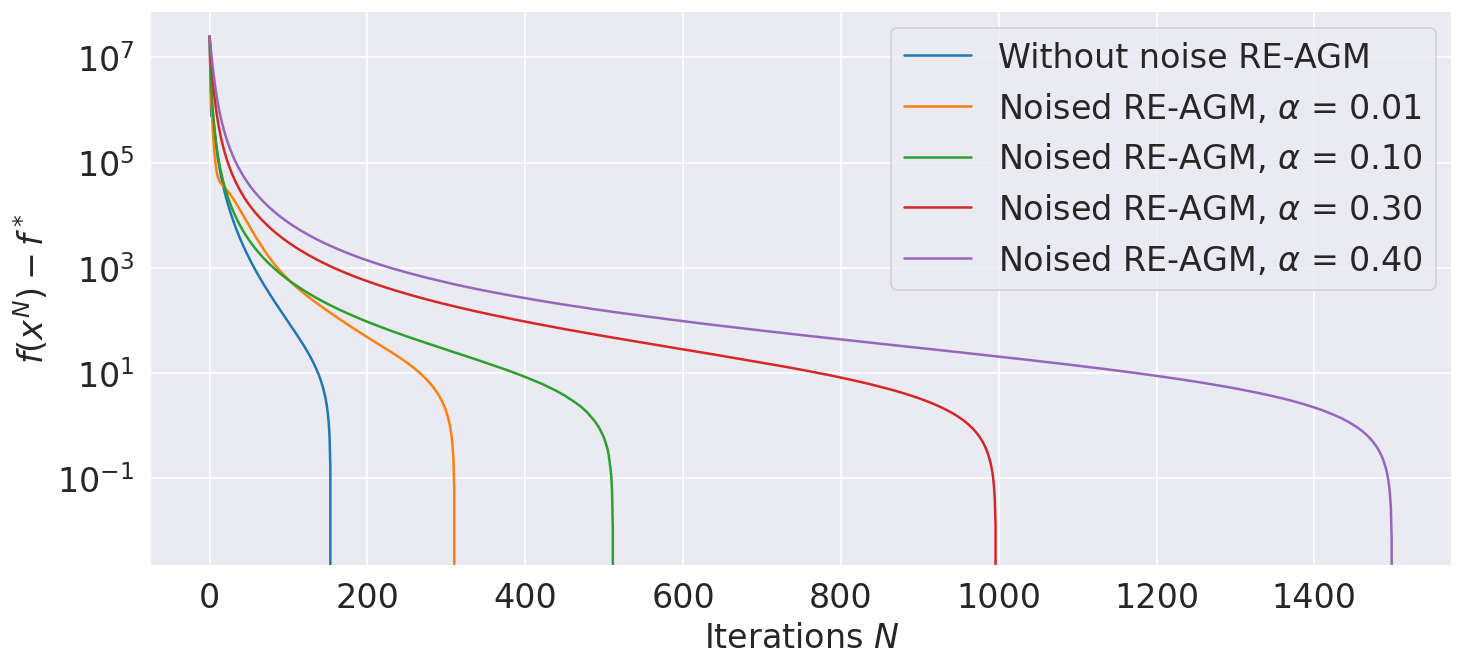

In [26]:
_ = plot(1500, alphas=[0.01, 0.1, 0.3, 0.4], mu=0.01, L=100, dig_a=2, dig_mu=2, name="100_001")

/tmp/ipykernel_105141/260007457.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iters)):


  0%|          | 0/1400 [00:00<?, ?it/s]

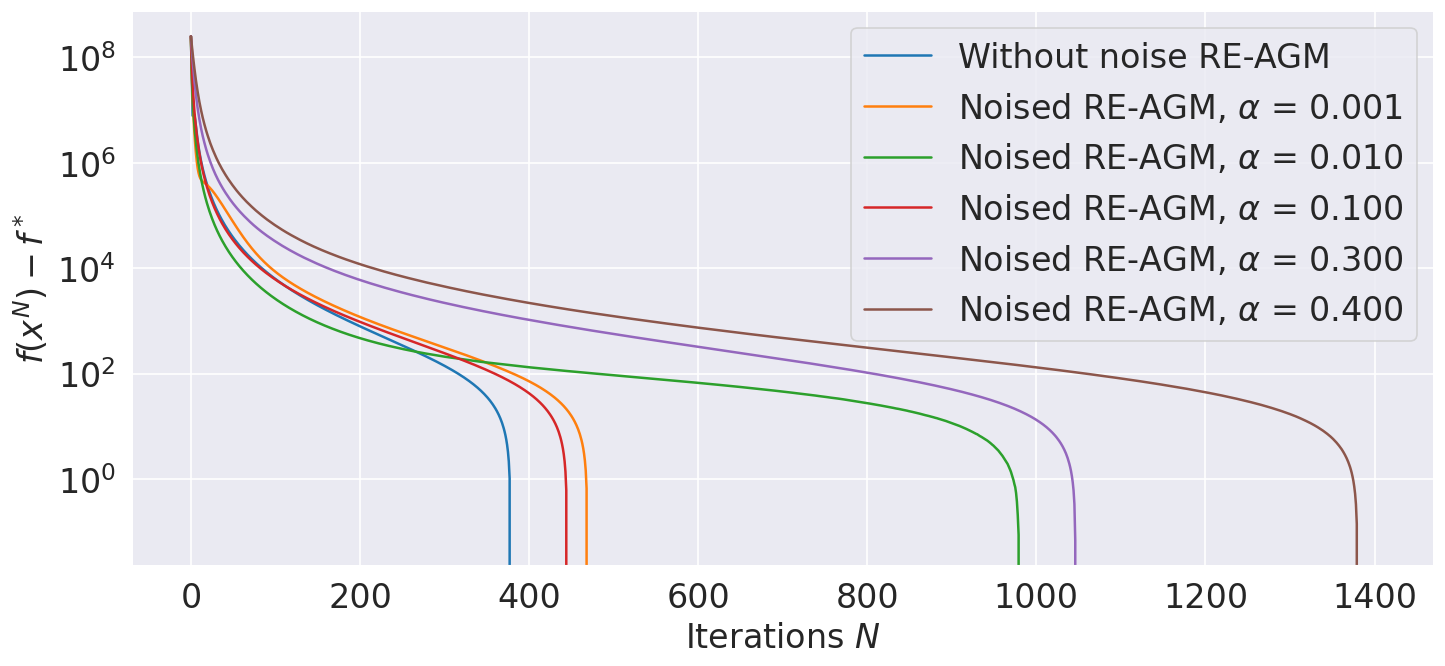

In [31]:
_ = plot(1400, alphas=[0.001, 0.01, 0.1, 0.3, 0.4], mu=0.001, L=1000, dig_a=3, dig_mu=3, name="1000_0001")

/tmp/ipykernel_105141/260007457.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iters)):


  0%|          | 0/2000 [00:00<?, ?it/s]

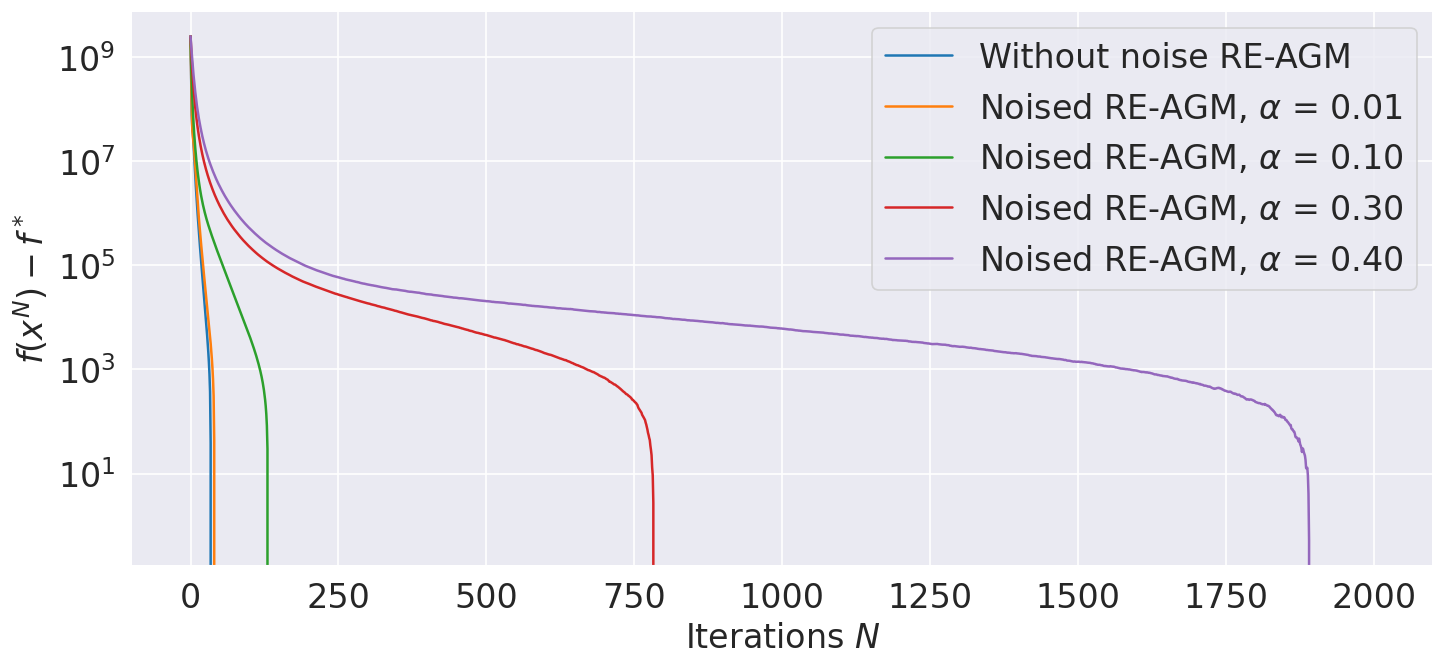

In [28]:
_ = plot(2000, alphas=[0.01, 0.1, 0.3, 0.4], mu=100, L=10000, dig_a=2, dig_mu=0, name="10000_100")

/tmp/ipykernel_105141/260007457.py:19: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iters)):


  0%|          | 0/1400 [00:00<?, ?it/s]

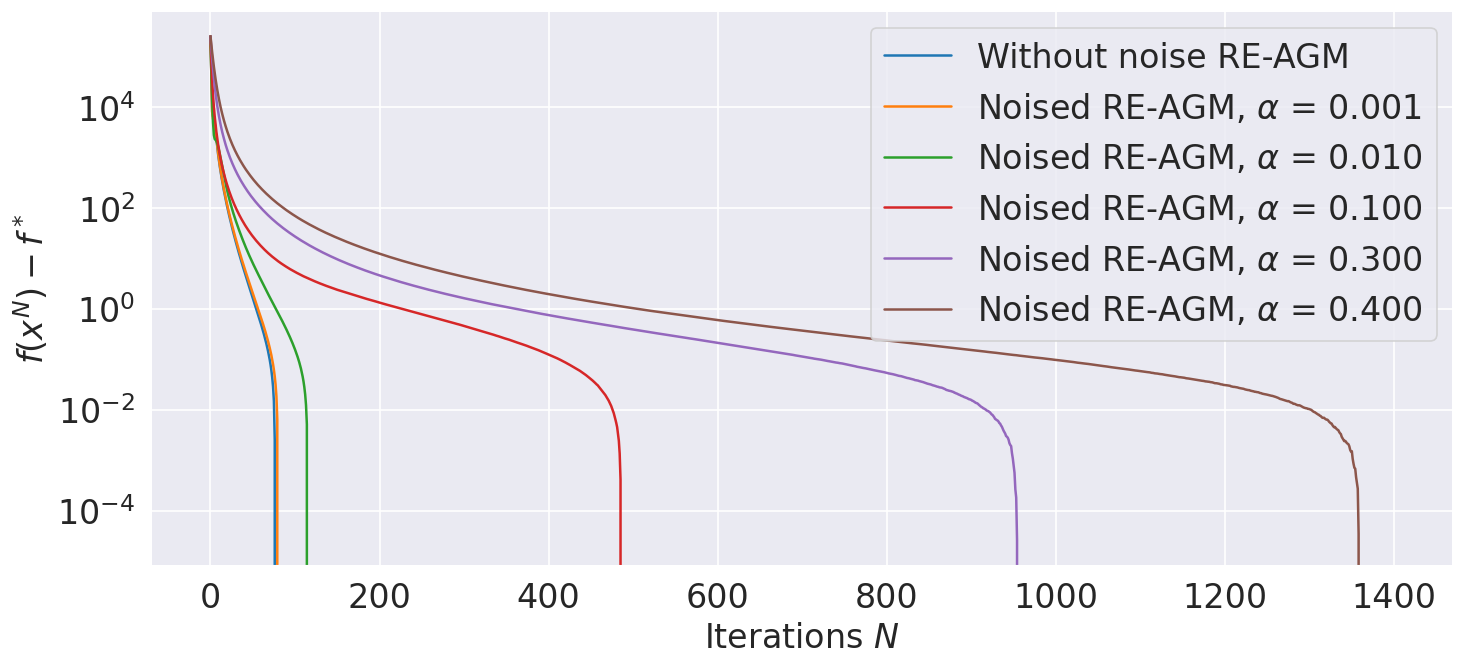

In [29]:
_ = plot(1400, alphas=[0.001, 0.01, 0.1, 0.3, 0.4], mu=0.001, L=1, dig_a=3, dig_mu=3, name="1_0001")